In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import os
from tqdm import tqdm
import s3fs
import joblib
from scipy import stats

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Helper Classes

In [2]:
class ModelComparison:
    """Compare SARIMA and Prophet models."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3')
        self.df_train = None
        self.df_test = None
        self.sarima_model = None
        self.prophet_model = None
        self.df_forecast_sarima = None
        self.df_forecast_prophet = None
        self.dict_metrics_sarima = {}
        self.dict_metrics_prophet = {}
    
    def import_splits(self):
        """Load train/test splits."""
        str_train_uri = f's3://{self.str_bucket}/02_preprocessing/train_data.csv'
        str_test_uri = f's3://{self.str_bucket}/02_preprocessing/test_data.csv'
        
        self.df_train = pd.read_csv(str_train_uri)
        self.df_test = pd.read_csv(str_test_uri)
        
        self.df_train['date'] = pd.to_datetime(self.df_train['date'])
        self.df_test['date'] = pd.to_datetime(self.df_test['date'])
        
        print(f'Loaded splits: {len(self.df_train)} train, {len(self.df_test)} test')
        return self.df_train, self.df_test
    
    def load_models(self):
        """Load serialized SARIMA and Prophet models."""
        try:
            # Download from S3
            self.s3_client.download_file(
                self.str_bucket,
                '03_sarima/sarima_model.pkl',
                './sarima_model.pkl'
            )
            self.sarima_model = joblib.load('./sarima_model.pkl')
            print('Loaded SARIMA model')
        except Exception as e:
            print(f'Could not load SARIMA model: {e}')
        
        try:
            self.s3_client.download_file(
                self.str_bucket,
                '04_prophet/prophet_model.pkl',
                './prophet_model.pkl'
            )
            self.prophet_model = joblib.load('./prophet_model.pkl')
            print('Loaded Prophet model')
        except Exception as e:
            print(f'Could not load Prophet model: {e}')
    
    def generate_forecasts(self):
        """Generate forecasts from both models on test set."""
        # SARIMA forecast
        if self.sarima_model:
            forecast_result = self.sarima_model.get_forecast(steps=len(self.df_test))
            df_ci = forecast_result.conf_int(alpha=0.05)
            self.df_forecast_sarima = df_ci.copy()
            self.df_forecast_sarima.columns = ['ci_lower', 'ci_upper']
            self.df_forecast_sarima['forecast'] = forecast_result.predicted_mean.values
            self.df_forecast_sarima['model'] = 'SARIMA'
            print('Generated SARIMA forecast')
        
        # Prophet forecast
        if self.prophet_model:
            df_future = self.prophet_model.make_future_dataframe(periods=len(self.df_test), freq='MS')
            forecast = self.prophet_model.predict(df_future)
            df_forecast_future = forecast[forecast['ds'] > self.df_train['date'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
            
            self.df_forecast_prophet = df_forecast_future.copy()
            self.df_forecast_prophet.columns = ['date', 'forecast', 'ci_lower', 'ci_upper']
            self.df_forecast_prophet['model'] = 'Prophet'
            print('Generated Prophet forecast')
    
    def calculate_metrics(self):
        """Calculate evaluation metrics for both models."""
        arr_actual = self.df_test['attrition_rate'].values
        
        if self.df_forecast_sarima is not None:
            arr_pred_sarima = self.df_forecast_sarima['forecast'].values[:len(arr_actual)]
            flt_rmse_sarima = np.sqrt(np.mean((arr_actual - arr_pred_sarima) ** 2))
            flt_mae_sarima = np.mean(np.abs(arr_actual - arr_pred_sarima))
            flt_mape_sarima = np.mean(np.abs((arr_actual - arr_pred_sarima) / arr_actual)) * 100
            
            self.dict_metrics_sarima = {
                'Model': 'SARIMA',
                'RMSE': flt_rmse_sarima,
                'MAE': flt_mae_sarima,
                'MAPE': flt_mape_sarima
            }
        
        if self.df_forecast_prophet is not None:
            arr_pred_prophet = self.df_forecast_prophet['forecast'].values[:len(arr_actual)]
            flt_rmse_prophet = np.sqrt(np.mean((arr_actual - arr_pred_prophet) ** 2))
            flt_mae_prophet = np.mean(np.abs(arr_actual - arr_pred_prophet))
            flt_mape_prophet = np.mean(np.abs((arr_actual - arr_pred_prophet) / arr_actual)) * 100
            
            self.dict_metrics_prophet = {
                'Model': 'Prophet',
                'RMSE': flt_rmse_prophet,
                'MAE': flt_mae_prophet,
                'MAPE': flt_mape_prophet
            }
    
    def plot_metrics_comparison(self):
        """Side-by-side metrics comparison."""
        df_comparison = pd.DataFrame([
            self.dict_metrics_sarima,
            self.dict_metrics_prophet
        ])
        
        print('\n=== METRICS COMPARISON ===')
        print(df_comparison.to_string(index=False))
        
        # Bar plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        metrics_list = ['RMSE', 'MAE', 'MAPE']
        colors = ['#1f77b4', '#ff7f0e']
        
        for int_idx, str_metric in enumerate(metrics_list):
            list_vals = [df_comparison[df_comparison['Model'] == 'SARIMA'][str_metric].values[0],
                         df_comparison[df_comparison['Model'] == 'Prophet'][str_metric].values[0]]
            axes[int_idx].bar(['SARIMA', 'Prophet'], list_vals, color=colors)
            axes[int_idx].set_title(str_metric, fontsize=12, fontweight='bold')
            axes[int_idx].set_ylabel(str_metric)
            axes[int_idx].grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for int_i, flt_val in enumerate(list_vals):
                axes[int_idx].text(int_i, flt_val, f'{flt_val:.4f}', ha='center', va='bottom')
        
        plt.tight_layout()
        str_path = f'{self.str_dirname_output}/16_metrics_comparison.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'\nSaved metrics plot to {str_path}')
        plt.show()
        
        return df_comparison
    
    def plot_forecast_overlay(self):
        """Overlay forecast plots from both models."""
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Training data
        ax.plot(self.df_train['date'], self.df_train['attrition_rate'], linewidth=2, 
               label='Training Data', marker='o', markersize=4, color='#1f77b4')
        
        # Test data
        ax.plot(self.df_test['date'], self.df_test['attrition_rate'], linewidth=2.5, 
               label='Test Data (Actual)', marker='s', markersize=5, color='#2ca02c')
        
        # SARIMA forecast
        if self.df_forecast_sarima is not None:
            ax.plot(self.df_test['date'], self.df_forecast_sarima['forecast'].values[:len(self.df_test)], 
                   linewidth=2.5, label='SARIMA Forecast', marker='^', markersize=5, color='#ff7f0e')
        
        # Prophet forecast
        if self.df_forecast_prophet is not None:
            ax.plot(self.df_test['date'], self.df_forecast_prophet['forecast'].values[:len(self.df_test)], 
                   linewidth=2.5, label='Prophet Forecast', marker='d', markersize=5, color='#d62728')
        
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Attrition Rate', fontsize=11)
        ax.set_title('Model Forecast Comparison', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        str_path = f'{self.str_dirname_output}/17_forecast_overlay.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved overlay plot to {str_path}')
        plt.show()
    
    def plot_residuals_comparison(self):
        """Compare residuals from both models."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        arr_actual = self.df_test['attrition_rate'].values
        
        # SARIMA residuals
        if self.df_forecast_sarima is not None:
            arr_resid_sarima = arr_actual - self.df_forecast_sarima['forecast'].values[:len(arr_actual)]
            
            axes[0, 0].hist(arr_resid_sarima, bins=15, alpha=0.7, edgecolor='black', color='#ff7f0e')
            axes[0, 0].set_title('SARIMA Residual Distribution', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Residual')
            axes[0, 0].grid(True, alpha=0.3, axis='y')
            
            axes[1, 0].plot(arr_resid_sarima, linewidth=1.5, marker='o', markersize=4, color='#ff7f0e')
            axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            axes[1, 0].set_title('SARIMA Residuals Over Time', fontsize=12, fontweight='bold')
            axes[1, 0].set_ylabel('Residual')
            axes[1, 0].grid(True, alpha=0.3)
        
        # Prophet residuals
        if self.df_forecast_prophet is not None:
            arr_resid_prophet = arr_actual - self.df_forecast_prophet['forecast'].values[:len(arr_actual)]
            
            axes[0, 1].hist(arr_resid_prophet, bins=15, alpha=0.7, edgecolor='black', color='#d62728')
            axes[0, 1].set_title('Prophet Residual Distribution', fontsize=12, fontweight='bold')
            axes[0, 1].set_xlabel('Residual')
            axes[0, 1].grid(True, alpha=0.3, axis='y')
            
            axes[1, 1].plot(arr_resid_prophet, linewidth=1.5, marker='o', markersize=4, color='#d62728')
            axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            axes[1, 1].set_title('Prophet Residuals Over Time', fontsize=12, fontweight='bold')
            axes[1, 1].set_ylabel('Residual')
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        str_path = f'{self.str_dirname_output}/18_residuals_comparison.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved residuals plot to {str_path}')
        plt.show()

## Constants

In [3]:
str_bucket = 'time-series-forecasting-demo'
str_task = 'employee_attrition_forecasting'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

print(f'Output directory: {str_dirname_output}')

Output directory: ./output


## Load Data and Models

In [5]:
comparison = ModelComparison(str_bucket, str_dirname_output)
df_train, df_test = comparison.import_splits()
comparison.load_models()

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Loaded splits: 60 train, 12 test
Loaded SARIMA model
Loaded Prophet model


In [6]:
df_train

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2020-01-01,4544,705,686,0.151490,39.574227,7.103333
1,2020-01-31,4536,737,709,0.152697,40.776099,7.144393
2,2020-03-01,4570,546,554,0.117528,47.304553,7.200532
3,2020-03-31,4442,550,529,0.115409,41.572898,7.180251
4,2020-04-30,4451,512,494,0.106330,44.398178,6.717739
5,2020-05-30,4499,472,449,0.101233,42.774684,6.534091
6,2020-06-29,4505,381,357,0.076328,44.629461,7.709531
7,2020-07-29,4474,321,335,0.076421,38.959565,7.260049
8,2020-08-28,4465,466,415,0.089941,42.666650,6.891383
9,2020-09-27,4345,644,596,0.136549,46.852306,6.391925


In [7]:
df_test

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2024-12-05,4496,492,446,0.094206,40.761716,7.014290
1,2025-01-04,4566,719,719,0.153480,38.886842,7.248555
2,2025-02-03,4549,657,640,0.135840,42.846596,7.841359
3,2025-03-05,4467,586,546,0.120267,37.931673,7.101528
4,2025-04-04,4623,485,475,0.100799,40.504860,6.622151
5,2025-05-04,4576,478,451,0.100968,44.721990,6.941815
6,2025-06-03,4569,354,343,0.074768,44.019060,7.136780
7,2025-07-03,4625,344,334,0.072719,42.300419,7.027890
8,2025-08-02,4585,444,440,0.092368,38.182424,7.468765
9,2025-09-01,4494,614,601,0.130019,42.470115,6.800370


## Generate Forecasts

In [8]:
comparison.generate_forecasts()

Generated SARIMA forecast
Generated Prophet forecast


## Calculate Metrics

In [9]:
comparison.calculate_metrics()

## Metrics Comparison Table


=== METRICS COMPARISON ===
  Model     RMSE      MAE      MAPE
 SARIMA 0.023962 0.020413 19.055033
Prophet 0.021593 0.017400 15.806224

Saved metrics plot to ./output/16_metrics_comparison.png


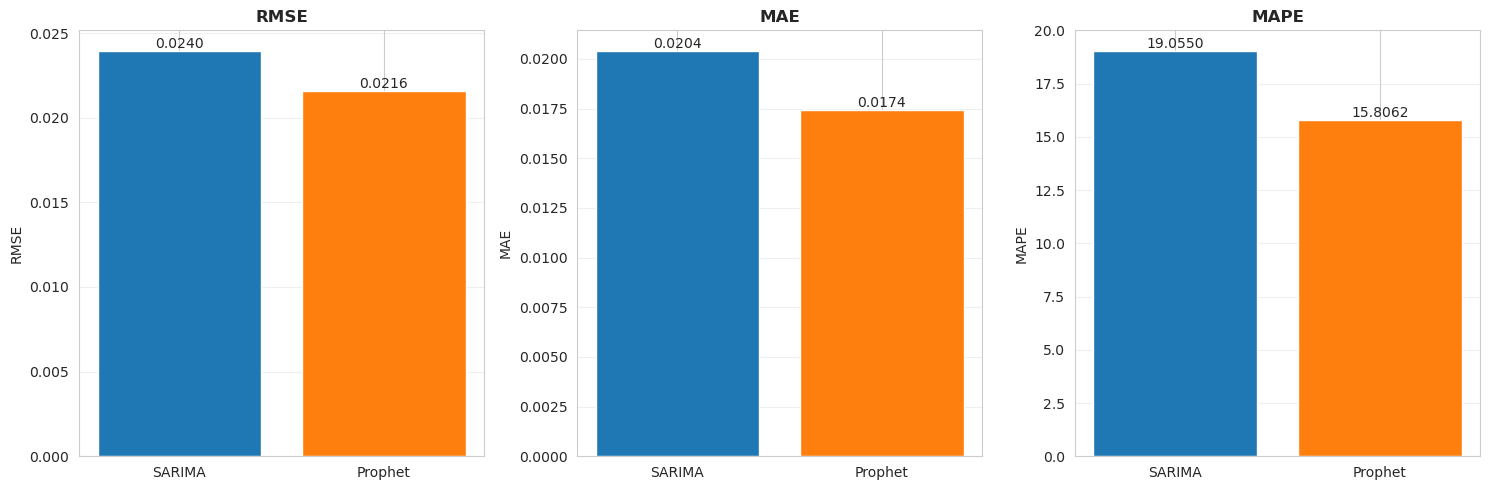

In [10]:
df_metrics = comparison.plot_metrics_comparison()

## Forecast Overlay Plot

Saved overlay plot to ./output/17_forecast_overlay.png


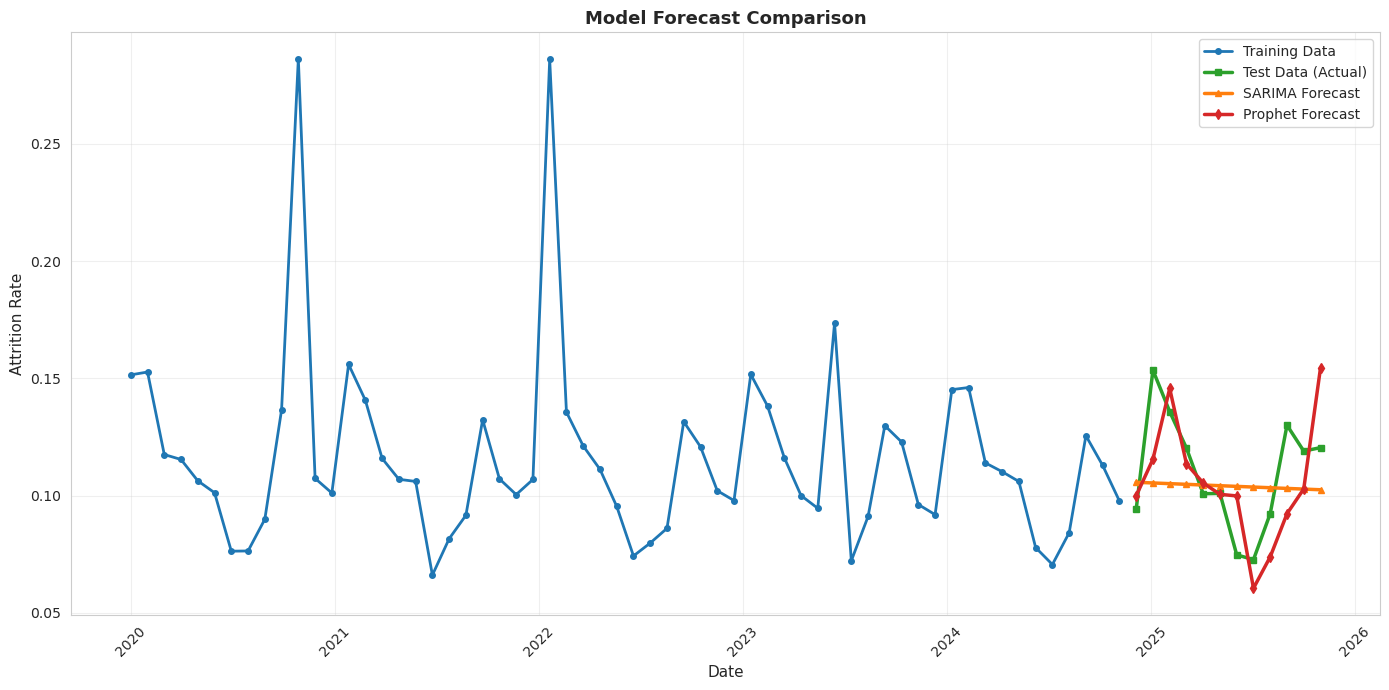

In [11]:
comparison.plot_forecast_overlay()

## Residuals Comparison

Saved residuals plot to ./output/18_residuals_comparison.png


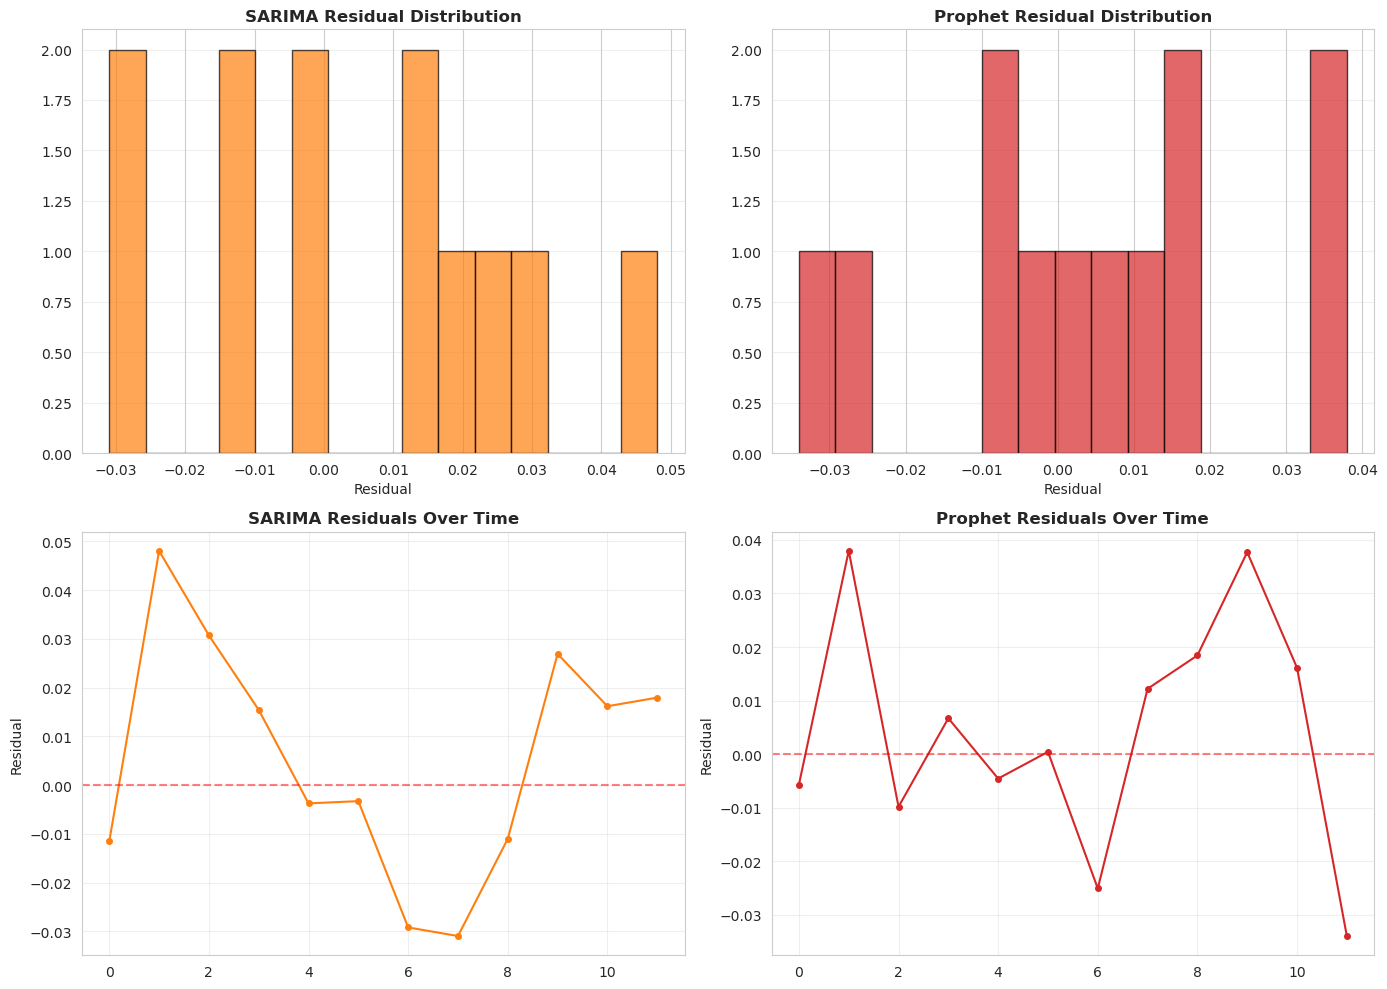

In [12]:
comparison.plot_residuals_comparison()

## Final Comparison Summary

In [13]:
print(f'\n=== FINAL MODEL COMPARISON ===')
print(f'\nDataset:')
print(f'  Train samples: {len(df_train)}')
print(f'  Test samples: {len(df_test)}')
print(f'\nModel Performance:')
print(df_metrics.to_string(index=False))

# Determine winner
if comparison.dict_metrics_sarima and comparison.dict_metrics_prophet:
    flt_mape_sarima = comparison.dict_metrics_sarima['MAPE']
    flt_mape_prophet = comparison.dict_metrics_prophet['MAPE']
    
    str_winner = 'SARIMA' if flt_mape_sarima < flt_mape_prophet else 'Prophet'
    flt_improvement = abs(flt_mape_sarima - flt_mape_prophet)
    
    print(f'\nWinner: {str_winner} (MAPE difference: {flt_improvement:.2f}%)')
    print(f'\nRecommendation:')
    if str_winner == 'SARIMA':
        print(f'  - SARIMA provides superior accuracy for production forecasting')
        print(f'  - Prophet offers better interpretability of trend/seasonality')
        print(f'  - Consider ensemble approach for robustness')
    else:
        print(f'  - Prophet provides superior accuracy and interpretability')
        print(f'  - Easier to integrate seasonality and trend changes')
        print(f'  - Better for stakeholder communication')

print(f'\n=== COMPARISON COMPLETE ===')


=== FINAL MODEL COMPARISON ===

Dataset:
  Train samples: 60
  Test samples: 12

Model Performance:
  Model     RMSE      MAE      MAPE
 SARIMA 0.023962 0.020413 19.055033
Prophet 0.021593 0.017400 15.806224

Winner: Prophet (MAPE difference: 3.25%)

Recommendation:
  - Prophet provides superior accuracy and interpretability
  - Easier to integrate seasonality and trend changes
  - Better for stakeholder communication

=== COMPARISON COMPLETE ===
